In [2]:
import openseespywin as ops
import opsvis as opsv 
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math
import opstool as opst
#import eurocodepy as ecpy
import time as tt
import pandas as pd
import ipywidgets as widgets
from blueprints.codes.formula import Formula
from blueprints.codes.latex_formula import LatexFormula, latex_replace_symbols
from blueprints.type_alias import DIMENSIONLESS, DEG, KG, N, MM, MM2, MM3, MM4, MPA, KNM, M, KN, NMM
from IPython.display import Math, display
# import openseespy.postprocessing.Get_Rendering as opsplt

In [3]:
opst.add_ops_hints_file()

OPSTOOL :: opensees.pyi file has been created to 
C:\Users\micha\miniconda3\envs\blue_env\Lib\site-packages\openseespywin\opensees.pyi!

In [4]:
import sys
sys.path.append('Data')
import functions.solver_function as SF
import importlib
importlib.reload(SF)
from functions.solver_function import *

In [5]:
length_unit = "m"  # base unit
force_unit = "kN"  # base unit

UNIT = opst.pre.UnitSystem(length=length_unit, force=force_unit)

print("Length:", UNIT.mm, UNIT.mm2, UNIT.cm, UNIT.m,)
print("Force", UNIT.N, UNIT.kN, )
print("Stress", UNIT.MPa, UNIT.kPa, UNIT.Pa, )
print("Mass", UNIT.g, UNIT.kg, UNIT.ton)
print(UNIT)

Length: 0.001 1e-06 0.01 1
Force 0.001 1
Stress 1000.0 1.0 0.001
Mass 1e-06 0.001 1.0
<UnitSystem: length='m', force='kn', time='sec' (102410246944)>


In [6]:
import openseespy.opensees as ops

#Soil Element Properties
soil_thickness = 1.0
etype = "PlaneStrain"

# Start model
ops.wipe()
ops.model("Basic", "-ndm", 2, "-ndf", 2)

ops.nDMaterial(
            "PressureDependMultiYield02",
            5,#tag
            2,#Number of dimension
            1.8*UNIT.ton/UNIT.m3,#rho
            9.6*10**4*UNIT.kpa,#ref shear modulus
            22.0*10**4*UNIT.kpa,#ref bulk modulus
            36, #friction angle
            0.1,#peak shear stress
            101.0*UNIT.kpa,#ref pressure
            0.0,#pressure dependence coefficient
            26, #PTAng
            0.067,#contrac1
            0.23,#contrac3
            0.067,#dilatation1
            0.27,#dilatation3
            20,#noYieldsurf
            5.0,#contrac2
            3.0,#dilatation2
            1.0,#liquefaction1
            0.0,#liquefaction2
            0.77,#e
            0.9,#cs1
            0.02,#cs2
            0.7,#cs3
            101.0,#pa
        )
soil_mat_tag = 1

ops.nDMaterial("InitialStateAnalysisWrapper", soil_mat_tag, 5, 2)

    #elasto_mat_tag = 100
    # Define material
    #ops.nDMaterial("ElasticIsotropic", elasto_mat_tag, E, nu, rho)

    # Define contact material
contact_mat = 2
ops.nDMaterial("ContactMaterial2D", contact_mat, 0.3, 50*UNIT.kpa, 0.0, 0.0) #50kPa refer to reference Some_Aspects_of_Shear_Behavior_of_Soft_Soil-Concre

# Generate one block starting from node 1 and element 1
node_offset = 0
elem_offset = 1
node_offset, elem_offset = SF.generate_block(-10.0, 0.0, 20.0, 8.0, node_offset, elem_offset, etype, soil_mat_tag, soil_thickness, 1.0 , 1.0, block_name="OAE_Soil_block")
node_offset, elem_offset = SF.generate_block(-10.0, 9.0, 4.0, 10.0, node_offset, elem_offset, etype, soil_mat_tag, soil_thickness, 1.0 , 1.0, block_name="OAE_Soil_block")
node_offset, elem_offset = SF.generate_block(6.0, 9.0, 4.0, 10.0, node_offset, elem_offset, etype, soil_mat_tag, soil_thickness, 1.0 , 1.0, block_name="OAE_Soil_block")
node_offset, elem_offset = SF.generate_block(-10, 20.0, 20.0, 5.0, node_offset, elem_offset, etype, soil_mat_tag, soil_thickness, 1.0 , 1.0, block_name="OAE_Soil_block")

InitialStateAnalysisWrapper nDmaterial - Written: C.McGann, P.Arduino, P.Mackenzie-Helnwein, U.Washington
ContactMaterial2D nDmaterial - Written: K.Petek, P.Mackenzie-Helnwein, P.Arduino, U.Washington


In [7]:
existing_tags = ops.getNodeTags()
start_id = max(existing_tags) + 1 if existing_tags else 1
print(start_id)

426


In [8]:
interface_nodes_coor = [
[-4.0000 , 19.000],
[-5.0000 , 19.000],
[-5.0000 , 18.000],
[-5.0000 , 10.000],
[-5.0000 ,  9.000],
[-4.0000 ,  9.000],
[ 4.0000 ,  9.000],
[ 5.0000 ,  9.000],
[ 5.0000 , 10.000],
[ 5.0000 , 18.000],
[ 5.0000 , 19.000],
[ 4.0000 , 19.000],
[-0.7832 ,19.9487],
[-1.5529 ,19.7956],
[-2.2961 ,19.5433],
[-3.0000 ,19.1962],
[-3.6526 ,18.7601],
[-4.2426 ,18.2426],
[-4.7601 ,17.6526],
[-5.1962 ,17.0000],
[-5.5433 ,16.2961],
[-5.7956 ,15.5529],
[-5.9487 ,14.7832],
[-5.9487 ,  13.2168],
[-5.7956 ,  12.4471],
[-5.5433 ,  11.7039],
[-5.1962 ,  11.0000],
[-4.7601 ,  10.3474],
[-4.2426 ,   9.7574],
[-3.6526 ,   9.2399],
[-3.0000 ,   8.8038],
[-2.2961 ,   8.4567],
[-1.5529 ,   8.2044],
[-0.7832 ,   8.0513],
[0.7832 , 19.9487],
[1.5529 , 19.7956],
[2.2961 , 19.5433],
[3.0000 , 19.1962],
[3.6526 , 18.7601],
[4.2426 , 18.2426],
[4.7601 , 17.6526],
[5.1962 , 17.0000],
[5.5433 , 16.2961],
[5.7956 , 15.5529],
[5.9487 , 14.7832],
[5.9487 , 13.2168],
[5.7956 , 12.4471],
[5.5433 , 11.7039],
[5.1962 , 11.0000],
[4.7601 , 10.3474],
[4.2426 ,  9.7574],
[3.6526 ,  9.2399],
[3.0000 ,  8.8038],
[2.2961 ,  8.4567],
[1.5529 ,  8.2044],
[0.7832 ,  8.0513],
]

interface_coor = SF.add_nodes_from_coordinates(coord_list = interface_nodes_coor, start_id = start_id , block_name = "interface_nodes")

In [9]:
interface_nodes_point = block_registry["interface_nodes"]["nodes"]
print(interface_nodes_point)

[426, 427, 428, 429, 430, 431, 432, 433, 434, 435, 436, 437, 438, 439, 440, 441, 442, 443, 444, 445, 446, 447, 448, 449, 450, 451, 452, 453, 454, 455, 456, 457, 458, 459, 460, 461, 462, 463, 464, 465, 466, 467, 468, 469, 470, 471, 472, 473, 474, 475, 476, 477, 478, 479, 480, 481]


In [10]:
last_eid = max(ops.getEleTags()) if ops.getEleTags() else 0
print("Last element ID:", last_eid)

Last element ID: 340


In [11]:
bottom_nodes = [438,439,440,441,442,443,444,445,446,447,448]
top_nodes = [309,308,307,306,426,427,428,239,234,229,224]

In [12]:
quads_A = SF.create_quad_strip_from_nodes(
    edge1_nodes=bottom_nodes,
    edge2_nodes=top_nodes,
    start_elem_id=350,
    thickness=soil_thickness,
    etype="PlaneStrain",
    mat_tag=soil_mat_tag,
    block_name="quad_band_A"
)

In [13]:
bottom_nodes = [214,209,204,199,429,430,431,175,176,177,178]
top_nodes = [449,450,451,452,453,454,455,456,457,458,459]

In [14]:
quads_B = SF.create_quad_strip_from_nodes(
    edge1_nodes=bottom_nodes,
    edge2_nodes=top_nodes,
    start_elem_id=360,
    thickness=soil_thickness,
    etype="PlaneStrain",
    mat_tag=soil_mat_tag,
    block_name="quad_band_B"
)

In [15]:
bottom_nodes = [460,461,462,463,464,465,466,467,468,469,470]
top_nodes = [311,312,313,314,437,436,435,290,285,280,275]

In [16]:
quads_C = SF.create_quad_strip_from_nodes(
    edge1_nodes=bottom_nodes,
    edge2_nodes=top_nodes,
    start_elem_id=370,
    thickness=soil_thickness,
    etype="PlaneStrain",
    mat_tag=soil_mat_tag,
    block_name="quad_band_C"
)

In [17]:
bottom_nodes = [471,472,473,474,475,476,477,478,479,480,481]
top_nodes = [265,260,255,250,434,433,432,183,182,181,180]

In [18]:
quads_D = SF.create_quad_strip_from_nodes(
    edge1_nodes=bottom_nodes,
    edge2_nodes=top_nodes,
    start_elem_id=380,
    thickness=soil_thickness,
    etype="PlaneStrain",
    mat_tag=soil_mat_tag,
    block_name="quad_band_D"
)

In [19]:
bottom_nodes = [169,170,171,172,173,174,175]
top_nodes = [190,191,192,193,194,430,431]

In [20]:
quads_E = SF.create_quad_strip_from_nodes(
    edge1_nodes=bottom_nodes,
    edge2_nodes=top_nodes,
    start_elem_id=390,
    thickness=soil_thickness,
    etype="PlaneStrain",
    mat_tag=soil_mat_tag,
    block_name="quad_band_E"
)

In [21]:
bottom_nodes = [183,184,185,186,187,188,189]
top_nodes = [432,433,245,246,247,248,249]

In [22]:
quads_F = SF.create_quad_strip_from_nodes(
    edge1_nodes=bottom_nodes,
    edge2_nodes=top_nodes,
    start_elem_id=396,
    thickness=soil_thickness,
    etype="PlaneStrain",
    mat_tag=soil_mat_tag,
    block_name="quad_band_F"
)

In [23]:
bottom_nodes = [240,241,242,243,244,427,426]
top_nodes = [300,301,302,303,304,305,306]

In [24]:
quads_G = SF.create_quad_strip_from_nodes(
    edge1_nodes=bottom_nodes,
    edge2_nodes=top_nodes,
    start_elem_id=402,
    thickness=soil_thickness,
    etype="PlaneStrain",
    mat_tag=soil_mat_tag,
    block_name="quad_band_G"
)

In [25]:
bottom_nodes = [437,436,295,296,297,298,299]
top_nodes = [314,315,316,317,318,319,320]

In [26]:
quads_H = SF.create_quad_strip_from_nodes(
    edge1_nodes=bottom_nodes,
    edge2_nodes=top_nodes,
    start_elem_id=408,
    thickness=soil_thickness,
    etype="PlaneStrain",
    mat_tag=soil_mat_tag,
    block_name="quad_band_H"
)

In [27]:
ops.element("quad", 414, 310, 310, 309, 438, soil_thickness, etype, soil_mat_tag)
ops.element("quad", 415, 460, 460, 311, 310,  soil_thickness, etype, soil_mat_tag)
ops.element("quad", 416, 239, 428, 427, 244, soil_thickness, etype, soil_mat_tag)
ops.element("quad", 417, 435, 290, 295, 436, soil_thickness, etype, soil_mat_tag)
ops.element("quad", 418, 219, 219, 448, 224, soil_thickness, etype, soil_mat_tag)
ops.element("quad", 419, 219, 219, 214, 449, soil_thickness, etype, soil_mat_tag)
ops.element("quad", 420, 270, 270, 275, 470, soil_thickness, etype, soil_mat_tag)
ops.element("quad", 421, 270, 270, 471, 265, soil_thickness, etype, soil_mat_tag)
ops.element("quad", 422, 194, 430, 429, 199, soil_thickness, etype, soil_mat_tag)
ops.element("quad", 423, 459, 459, 178, 179, soil_thickness, etype, soil_mat_tag)
ops.element("quad", 424, 481, 481, 179, 180, soil_thickness, etype, soil_mat_tag)
ops.element("quad", 425, 433, 245, 250, 434, soil_thickness, etype, soil_mat_tag)

In [28]:
# Fixity definitions
fixXY = [1, 1]
fixXonly = [1, 0]
fixYonly = [0, 1]

# Inputs
start_id = 2
end_id = 20
step = 1

# Generate node list
bottom_nodes = list(range(start_id, end_id + 1, step))

# Apply fixity
for nid in bottom_nodes:
    ops.fix(nid, *fixYonly)


In [29]:
ops.fix(1, *fixXY)
ops.fix(21, *fixXY)

In [30]:
eqdof1 = SF.apply_equal_dof_by_range(
    primary_start= 22, primary_end = 169, primary_step = 21,
    secondary_start = 42, secondary_end = 189, secondary_step = 21,
    dofs=[1, 2], block_name="equal_dof_constraints_setA")

In [31]:
eqdof2 = SF.apply_equal_dof_by_range(
    primary_start= 190, primary_end = 240, primary_step = 5,
    secondary_start = 249, secondary_end = 299, secondary_step = 5,
    dofs=[1, 2], block_name="equal_dof_constraints_setB")

In [32]:
eqdof3 = SF.apply_equal_dof_by_range(
    primary_start= 300, primary_end = 405, primary_step = 21,
    secondary_start = 320, secondary_end = 425, secondary_step = 21,
    dofs=[1, 2], block_name="equal_dof_constraints_setC")

In [33]:
soil_nodes = [310, 438, 439, 440, 441, 442, 443, 444, 445, 446, 447, 448, 219, 449, 
              450, 451, 452, 453, 454, 455, 456, 457, 458, 459, 179, 481,480,479,478,
              477,476,475,474,473,473,471,270,470,469,468,467,466,465,464,463,462,461,460 ]

In [34]:
#soil_nodes_pad = [406,408,409,410,411,412,416]

In [35]:
#lagrange_nodes = SF.create_lagrange_nodes(start_id = 500, x_coord = -6.5, y_coord = 25.5, count = 9, block_name="lagrange_nodes")

In [36]:
#lagrange_nodes = block_registry["lagrange_nodes"]["nodes"]
#print(lagrange_nodes)

In [37]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=False, show_nodal_loads = True)

In [38]:
soil_slave_nodes = [409, 410, 411, 412, 413, 414, 415, 416, 417]

In [39]:
ops.model("Basic", "-ndm", 2, "-ndf", 3)

In [40]:
lining_nodes_coor = [
[ 0.0000,  20.0000],
[-0.7832,  19.9487],
[-1.5529,  19.7956],
[-2.2961,  19.5433],
[-3.0000,  19.1962],
[-3.6526,  18.7601],
[-4.2426,  18.2426],
[-4.7601,  17.6526],
[-5.1962,  17.0000],
[-5.5433,  16.2961],
[-5.7956,  15.5529],
[-5.9487,  14.7832],
[-6.0000,  14.0000],
[-5.9487,  13.2168],
[-5.7956,  12.4471],
[-5.5433,  11.7039],
[-5.1962,  11.0000],
[-4.7601,  10.3474],
[-4.2426,   9.7574],
[-3.6526,   9.2399],
[-3.0000,   8.8038],
[-2.2961,   8.4567],
[-1.5529,   8.2044],
[-0.7832,   8.0513],
[ 0.0000,   8.0000],
[ 0.7832,   8.0513],
[ 1.5529,   8.2044],
[ 2.2961,   8.4567],
[ 3.0000,   8.8038],
[ 3.6526,   9.2399],
[ 4.2426,   9.7574],
[ 4.7601,  10.3474],
[ 5.1962,  11.0000],
[ 5.5433,  11.7039],
[ 5.7956,  12.4471],
[ 5.9487,  13.2168],
[ 6.0000,  14.0000],
[ 5.9487,  14.7832],
[ 5.7956,  15.5529],
[ 5.5433,  16.2961],
[ 5.1962,  17.0000],
[ 4.7601,  17.6526],
[ 4.2426,  18.2426],
[ 3.6526,  18.7601],
[ 3.0000,  19.1962],
[ 2.2961,  19.5433],
[ 1.5529,  19.7956],
[ 0.7832,  19.9487],

]

lining_points = SF.add_nodes_from_coordinates(coord_list = lining_nodes_coor, start_id = 5000 , block_name = "lining_nodes_coor")

In [41]:
lining_points = block_registry["lining_nodes_coor"]["nodes"]
print(lining_points)

[5000, 5001, 5002, 5003, 5004, 5005, 5006, 5007, 5008, 5009, 5010, 5011, 5012, 5013, 5014, 5015, 5016, 5017, 5018, 5019, 5020, 5021, 5022, 5023, 5024, 5025, 5026, 5027, 5028, 5029, 5030, 5031, 5032, 5033, 5034, 5035, 5036, 5037, 5038, 5039, 5040, 5041, 5042, 5043, 5044, 5045, 5046, 5047]


In [42]:
pad_nodes_coor = [
[-6.0000 ,  25.0000],
[-5.0000 ,  25.0000],
[-4.0000 ,  25.0000],
[-3.0000 ,  25.0000],
[-2.0000 ,  25.0000],
[-1.0000 ,  25.0000],
[ 0.0000 ,  25.0000],
[ 1.0000 ,  25.0000],
[ 2.0000 ,  25.0000],
]

pad_nodes= SF.add_nodes_from_coordinates(coord_list = pad_nodes_coor, start_id = 6000 , block_name = "pad_nodes_coor")

In [43]:
pad_nodes = block_registry["pad_nodes_coor"]["nodes"]
print(pad_nodes)

[6000, 6001, 6002, 6003, 6004, 6005, 6006, 6007, 6008]


In [44]:
Iz = SF.FormRectangularInertia(b=1*UNIT.m , h=0.3*UNIT.m)
print(Iz)

0.00225


In [45]:
beam_nodes = lining_points + [5000] # Example node list (ordered start → end)
transFTag = 1
beam_secTag = 1
intTag = 401
Nint = 3
beam_start_id = 5000  # Starting element tag

# Geometry transformation and section definition
ops.geomTransf("Linear", transFTag)
ops.section("Elastic", beam_secTag, 35220*UNIT.mpa, 0.3*UNIT.M2, Iz)
ops.beamIntegration("Legendre", intTag, beam_secTag, Nint)

# Create elements
beam_elem_ids = []
for i in range(len(beam_nodes) - 1):
    sN = beam_nodes[i]
    eN = beam_nodes[i + 1]
    eid = beam_start_id + i
    ops.element("dispBeamColumn", eid, sN, eN, transFTag, intTag)
    created_elements.append((eid, sN, eN))
    beam_elem_ids.append(eid)

# Register block
block_registry["lining_beam"] = {
    "nodes": beam_nodes,
    "elements": beam_elem_ids
}

In [46]:
beam_nodes = pad_nodes
transFTag = 2
beam_secTag = 2
intTag = 402
Nint = 3
beam_start_id = 6000  # Starting element tag

# Geometry transformation and section definition
ops.geomTransf("Linear", transFTag)
ops.section("Elastic", beam_secTag, 35220*UNIT.mpa, 0.2*UNIT.M2, Iz)
ops.beamIntegration("Legendre", intTag, beam_secTag, Nint)

# Create elements
beam_elem_ids = []
for i in range(len(beam_nodes) - 1):
    sN = beam_nodes[i]
    eN = beam_nodes[i + 1]
    eid = beam_start_id + i
    ops.element("dispBeamColumn", eid, sN, eN, transFTag, intTag)
    created_elements.append((eid, sN, eN))
    beam_elem_ids.append(eid)

# Register block
block_registry["lining_beam"] = {
    "nodes": beam_nodes,
    "elements": beam_elem_ids
}

In [47]:
edof_lining = SF.apply_equal_dof_pairs(r_nodes = lining_points, c_nodes = soil_nodes, dofs=[1, 2], block_name="equal_dof_pairs_lining")
#edof_pad = SF.apply_equal_dof_pairs(r_nodes = pad_nodes, c_nodes = soil_nodes_pad, dofs=[1, 2], block_name="equal_dof_pairs_lining")

In [48]:
node_pairs = list(zip(pad_nodes, soil_slave_nodes))


In [49]:
contact_ids = SF.create_zero_length_contact_elements(
    node_pairs=node_pairs,
    start_elem_id=10000,
    Kn=1.0e9,
    Kt=10.0,
    mu=0.3,
    orientation=(0, 1, 0),
    block_name="pad_soil_contacts"
)


ZeroLengthContactASDimplex element - Implemented: Akan, OD., Petracca, M., Camata, G., Spacone, E. & Lai, CG. (2020)


In [50]:
# master_nodes = pad_nodes
# slave_nodes = soil_slave_nodes
# lagrange_nodes = lagrange_nodes
# 
# contact_elem_ids = []
# beam_start_id = 7000
# for i in range(len(slave_nodes)):
#     tag = beam_start_id + i
#     iN = master_nodes[i]
#     jN = master_nodes[i + 1]
#     sN = slave_nodes[i]
#     IN = lagrange_nodes[i]
# 
#     ops.element("BeamContact2D", tag, iN, jN, sN, IN, contact_mat, 1.0*UNIT.m, 1e-10, 1e-10)
#     created_elements.append((tag, iN, jN, sN, IN))
#     contact_elem_ids.append(tag)
# 
# block_registry["contact_beams_right"] = {
#     "nodes": master_nodes + slave_nodes + lagrange_nodes,
#     "elements": contact_elem_ids
# }

In [51]:
#ops.fix(6000, 0,1,0)
#ops.fix(6009, 1,1,0)

In [52]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=True, show_nodal_loads = True)

In [53]:
OPSVIS = opst.vis.pyvista

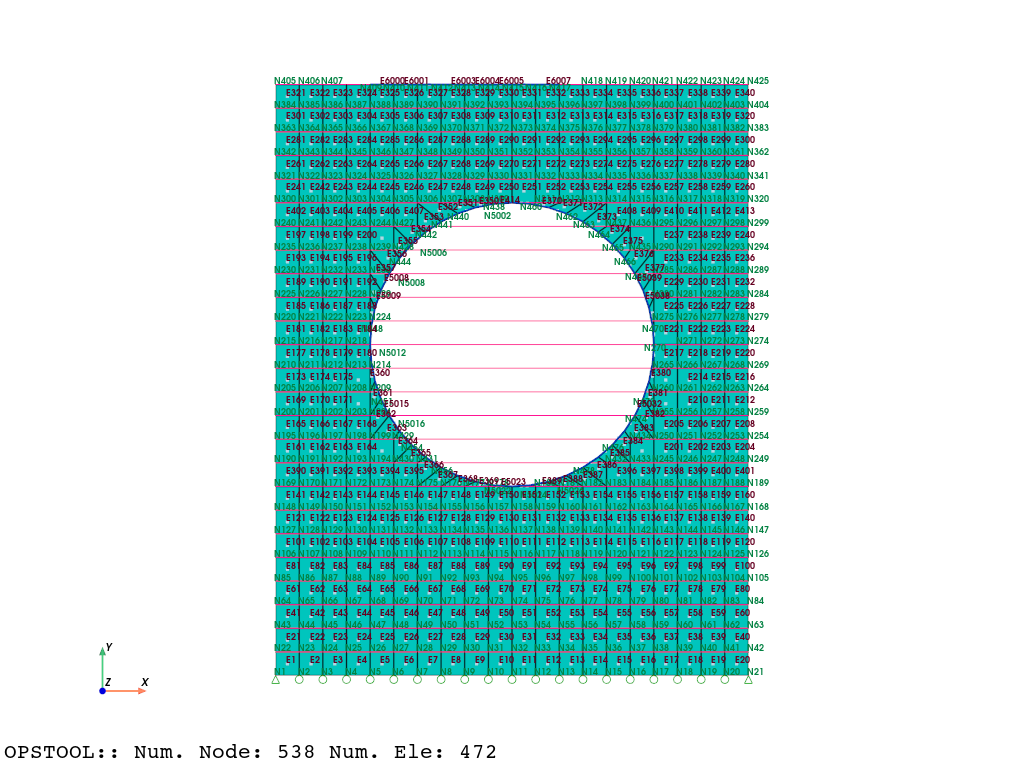

In [54]:
OPSVIS.set_plot_props(point_size=1, font_size=9, notebook=True)
OPSVIS.plot_model(show_node_numbering=True, show_ele_numbering=True).show(jupyter_backend="jupyterlab")

In [55]:
ODB = opst.post.CreateODB(
    odb_tag=1,
    model_update=True,
    compute_mechanical_measures=True,
    project_gauss_to_nodes="copy",
)

In [56]:
# define analysis parameters for gravity phase
ops.constraints("Transformation")
ops.test("NormDispIncr", 1e-05, 50, 0)
ops.algorithm("Newton")
ops.numberer("RCM")
ops.system("FullGeneral ") #FullGeneral #UmfPack
ops.integrator("LoadControl", 1)
ops.analysis("Static")

In [57]:
# turn on initial state analysis feature
ops.InitialStateAnalysis("on")
# ensure soil material intially considers linear elastic behavior
ops.updateMaterialStage("-material", 1, "-stage", 0)
# set contact elements to be frictionless for gravity analysis
#ops.setParameter("-val", 0, "-eleRange", 7000, 7008, "friction")
# analysis 4 steps, and fetch response
for _ in range(4):
    ops.analyze(1)
    ODB.fetch_response_step()

InitialStateAnalysis ON


In [58]:
# update soil material to consider elastoplastic behavior and analyze a few more steps
ops.updateMaterialStage("-material", 1, "-stage", 1)
# analysis 4 steps, and fetch response
for _ in range(4):
    ops.analyze(1)
    ODB.fetch_response_step()
# designate end of initial state analysis (zeros displacements, keeps state variables)
ops.InitialStateAnalysis("off")
# turn on frictional behavior for beam contact elements
#ops.setParameter("-val", 0, "-eleRange", 7000, 7008, "friction")

InitialStateAnalysis OFF
Domain::addParameter - parameter with tag 0 already exists in model


In [59]:
# define analysis parameters for excavation phase
ops.wipeAnalysis()
ops.constraints("Transformation")
ops.test("NormDispIncr", 0.0001, 60)
ops.algorithm("KrylovNewton")
ops.numberer("RCM")
ops.system("BandGeneral")
ops.integrator("LoadControl", 1)
ops.analysis("Static")

In [60]:
def remove_components(ele_tags, node_tags, nsteps=4):
    for etag in ele_tags:
        ops.remove("element", etag)
    for ntag in node_tags:
        ops.remove("node", ntag)
    # run analysis after object removal
    for _ in range(nsteps):
        ops.analyze(1)
        ODB.fetch_response_step()

In [61]:
ops.timeSeries("Linear", 1)
ops.pattern("Plain", 1, 1)
ops.load(6005, 0, -0.0001, 0)

In [62]:
ops.analyze(1)

0

In [63]:
# remove objects associated with lift 1
# soil elements
ele_tags = []
ele_tags += []  # contact element
# soil nodes
node_tags = []
node_tags += []  # lagrange multiplier node

remove_components(ele_tags, node_tags, nsteps=4)

print("Lift 1 removed")

Lift 1 removed


In [64]:
ops.load(6007, 0, -0.0001, 0)

In [65]:
ops.analyze(1)

0

In [66]:
# remove objects associated with lift 1
# soil elements
ele_tags = []
ele_tags += []  # contact element
# soil nodes
node_tags = []
node_tags += []  # lagrange multiplier node

remove_components(ele_tags, node_tags, nsteps=4)

print("Lift 2 removed")

Lift 2 removed


In [67]:
ODB.save_response(zlib=True)

OPSTOOL ::  All responses data with _odb_tag = 1 saved in .opstool.output/RespStepData-1.nc!

In [68]:
import matplotlib.pyplot as plt

import opstool as opst
import opstool.vis.pyvista as opsvis

In [69]:
opsvis.set_plot_props(point_size=0, line_width=5, cmap="turbo", notebook=True)
opsvis.set_plot_props(
    scalar_bar_kargs={
        "label_font_size": 12,
        "title_font_size": 13,
        "position_x": 0.85,  # 0--1
    }
)

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

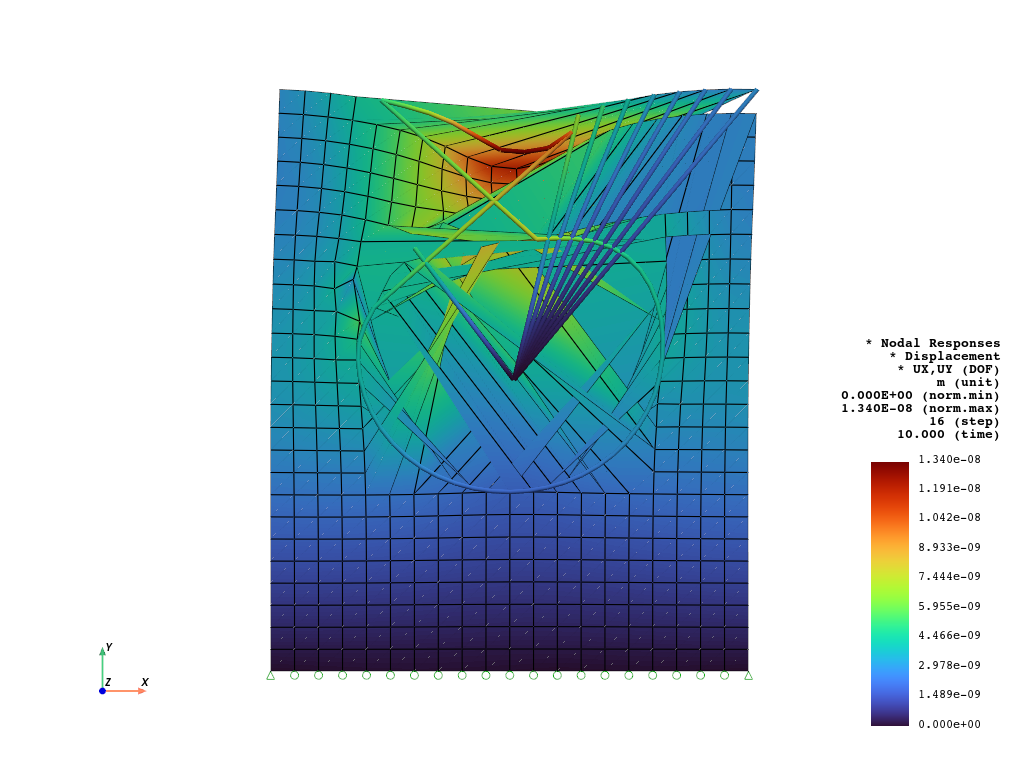

In [70]:
opsvis.plot_nodal_responses(
    odb_tag=1,
    slides=True,
    scale=2,
    resp_type="disp",
    resp_dof=["UX", "UY"],
    unit_symbol="m",
).show(jupyter_backend="juoyterlab")

In [71]:
opsvis.plot_nodal_responses_animation(
    odb_tag=1,
    framerate=2,
    scale=2,
    savefig="NodalRespAnimationA.gif",
    resp_type="disp",
    resp_dof=["UX", "UY"],
    unit_symbol="m",
).close()

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

: 

In [ ]:
plotter = opsvis.plot_frame_responses(
    odb_tag=1,
    resp_type="sectionForces",
    resp_dof="MZ",
    unit_symbol="kN·m",
    show_values="eleMaxMin",
    scale=3,
    slides=True,
    style="surface",
    show_model=False,  # plot all model
    opacity=1.0,
    show_bc=False,
)
plotter.show(jupyter_backend="jupyterlab")

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

IndexError: index 539 is out of bounds for axis 0 with size 539

In [ ]:
opsvis.plot_frame_responses_animation(
    odb_tag=1,
    resp_type="sectionForces",
    resp_dof="MZ",
    framerate=2,
    scale=3,
    line_width=4,
    savefig="FrameForcesMZ_A.gif",
).close()

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

IndexError: index 539 is out of bounds for axis 0 with size 539

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

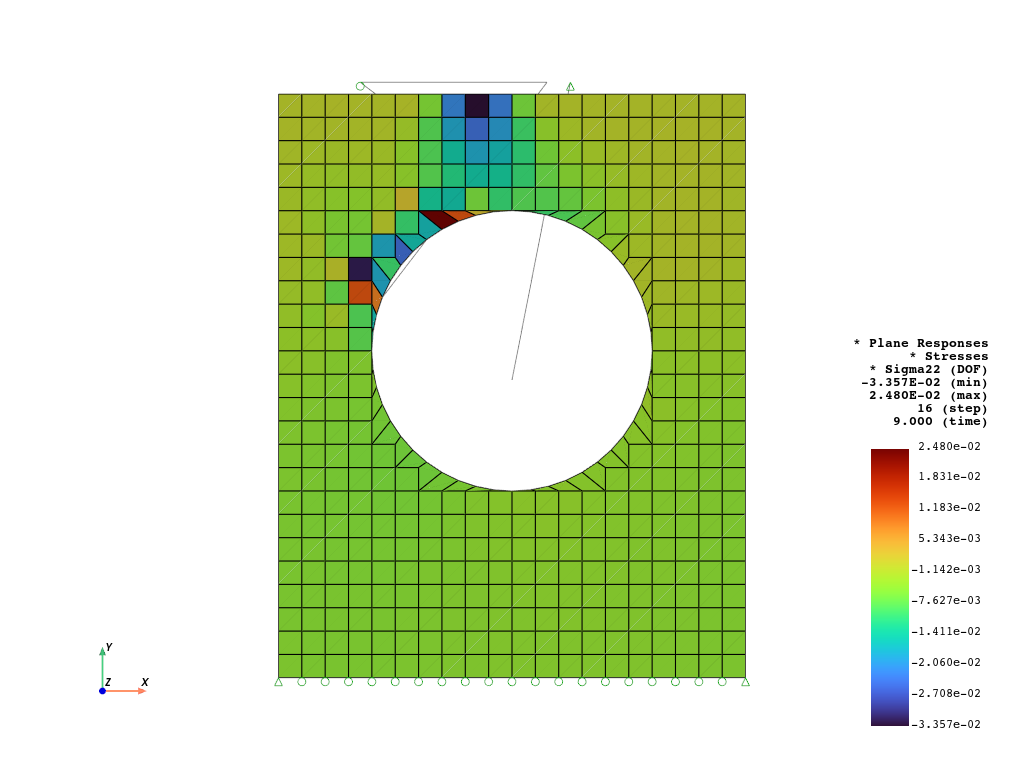

In [ ]:
opsvis.plot_unstruct_responses(
    odb_tag=1, slides=True, ele_type="Plane", resp_type="Stresses", resp_dof="sigma22"
).show(jupyter_backend="jupyterlab")

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

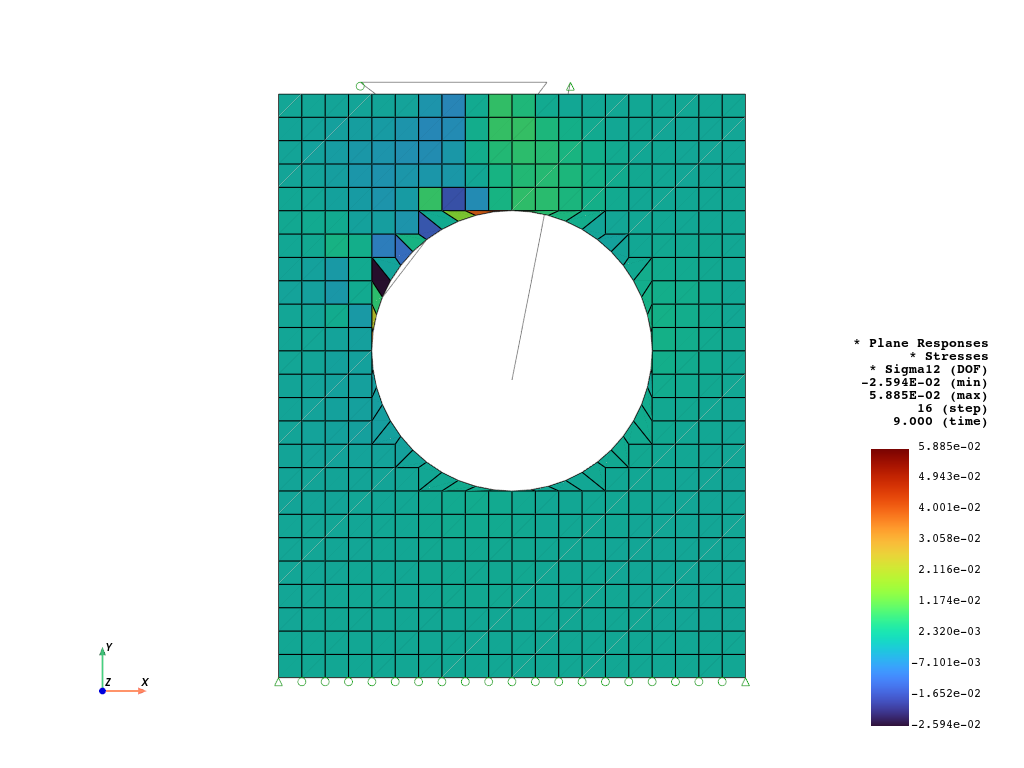

In [ ]:
opsvis.plot_unstruct_responses(
    odb_tag=1, slides=True, ele_type="Plane", resp_type="Stresses", resp_dof="sigma12"
).show(jupyter_backend="jupyterlab")

In [ ]:
data = opst.post.get_element_responses(odb_tag=1, ele_type="Contact")

OPSTOOL ::  Loading Contact response data from .opstool.output/RespStepData-1.nc ...

In [ ]:
print(data)

<xarray.Dataset> Size: 7kB
Dimensions:       (time: 17, eleTags: 9, globalDOFs: 3, localDOFs: 3,
                   slipDOFs: 2)
Coordinates:
  * eleTags       (eleTags) int64 72B 7000 7001 7002 7003 ... 7006 7007 7008
  * globalDOFs    (globalDOFs) <U2 24B 'Px' 'Py' 'Pz'
  * localDOFs     (localDOFs) <U2 24B 'N' 'Tx' 'Ty'
  * slipDOFs      (slipDOFs) <U2 16B 'Tx' 'Ty'
  * time          (time) float32 68B 0.0 1.0 2.0 3.0 4.0 ... 5.0 6.0 7.0 8.0 9.0
Data variables:
    globalForces  (time, eleTags, globalDOFs) float32 2kB -0.0 -0.0 ... -0.0 0.0
    localForces   (time, eleTags, localDOFs) float32 2kB 0.0 0.0 0.0 ... 0.0 0.0
    localDisp     (time, eleTags, localDOFs) float32 2kB 0.0 0.0 0.0 ... 0.0 0.0
    slips         (time, eleTags, slipDOFs) float32 1kB 0.0 0.0 0.0 ... 0.0 0.0
Attributes:
    Px:       Global force in the x-direction on the constrained node
    Py:       Global force in the y-direction on the constrained node
    Pz:       Global force in the z-direction on the con

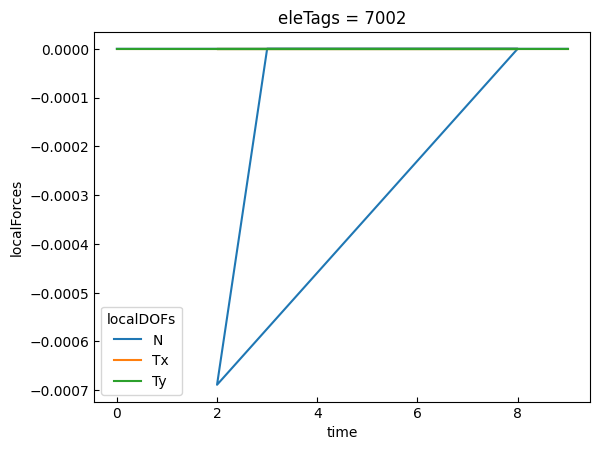

In [ ]:
data["localForces"].sel(eleTags=7002).plot.line(x="time")
plt.show()

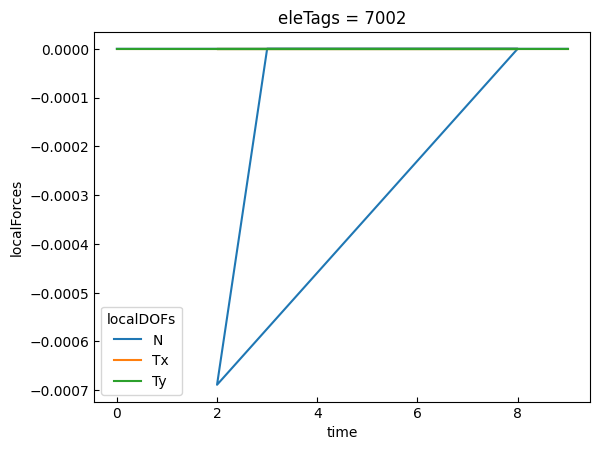

In [ ]:
data["localForces"].sel(eleTags=7002).plot.line(x="time")
plt.show()

In [ ]:
data["localForces"].sel(eleTags=7002).data

array([[ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [-0.00068887,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ]], dtype=float32)

In [ ]:
data["localDisp"].sel(eleTags=7002).data

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]], dtype=float32)

In [ ]:
data_frame = opst.post.get_element_responses(odb_tag=1, ele_type="Frame")

OPSTOOL ::  Loading Frame response data from .opstool.output/RespStepData-1.nc ...

In [ ]:
data_frame["basicForces"].sel(eleTags=7002).plot.line(x="time")
plt.show()

KeyError: "not all values found in index 'eleTags'. Try setting the `method` keyword argument (example: method='nearest')."

In [ ]:
data_frame["basicDeformations"].sel(eleTags=7002).plot.line(x="time")
plt.show()

KeyError: "not all values found in index 'eleTags'. Try setting the `method` keyword argument (example: method='nearest')."